**NAME: SAIRA JABEEN, ROLL NO:23-AI-10, SECTION: A2(B), TASK 01 (PLANT VILLAGE)**

In [3]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!pip install kaggle -q
!kaggle datasets download -d emmarex/plantdisease --unzip -p /content/PlantVillage
print("Done!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:08<00:00, 79.8MB/s]

Done!


In [4]:
import os

print(os.listdir())  # check folders

['.config', 'PlantVillage', 'sample_data']


In [5]:
data_path = "PlantVillage/PlantVillage"   # MOST IMPORTANT FIX

print("Classes:", os.listdir(data_path)[:5])

Classes: ['Tomato__Tomato_mosaic_virus', 'Pepper__bell___Bacterial_spot', 'Potato___Late_blight', 'Tomato_healthy', 'Potato___healthy']


In [6]:
import os

count = 0

for root, dirs, files in os.walk("/content/PlantVillage"):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            count += 1

print("Total images:", count)

Total images: 41276


In [11]:
import os

# Select first folder (class label)
folder = os.listdir(data_path)[0]

# Select first image inside that folder
img_name = os.listdir(os.path.join(data_path, folder))[0]

# Create full image path
sample_path = os.path.join(data_path, folder, img_name)

# Print path to verify
print(sample_path)

PlantVillage/PlantVillage/Tomato__Tomato_mosaic_virus/830ed62d-ec4b-4df9-97fe-fddf36d7c3cb___PSU_CG 2301.JPG


In [13]:
import cv2
import numpy as np

IMG_SIZE = 128

def preprocess_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply histogram equalization
    equalized = cv2.equalizeHist(gray)

    return equalized

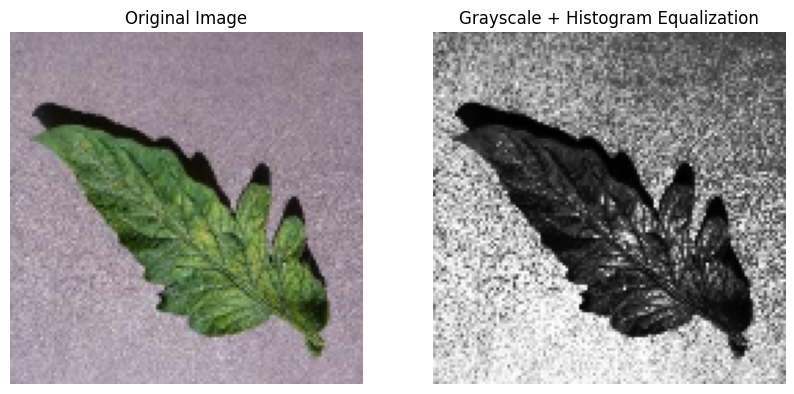

In [14]:
import cv2
import matplotlib.pyplot as plt

# Read original image
img_original = cv2.imread(sample_path)

# Resize image to fixed size
img_original = cv2.resize(img_original, (128,128))

# Apply preprocessing (grayscale + histogram equalization)
img_processed = preprocess_image(sample_path)

# Create comparison plot
plt.figure(figsize=(10,5))

# Show original image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Show processed grayscale image
plt.subplot(1,2,2)
plt.imshow(img_processed, cmap='gray')
plt.title("Grayscale + Histogram Equalization")
plt.axis('off')

# Display plots
plt.show()

In [17]:
import cv2
import numpy as np

def apply_filters(img):
    # Sobel filter in X direction (detects vertical edges)
    sobelx = cv2.filter2D(img, -1, np.array([[1,0,-1],
                                              [2,0,-2],
                                              [1,0,-1]]))

    # Sobel filter in Y direction (detects horizontal edges)
    sobely = cv2.filter2D(img, -1, np.array([[1,2,1],
                                              [0,0,0],
                                              [-1,-2,-1]]))

    # Laplacian filter (detects all edges)
    laplacian = cv2.filter2D(img, -1, np.array([[0,1,0],
                                                 [1,-4,1],
                                                 [0,1,0]]))

    return sobelx, sobely, laplacian

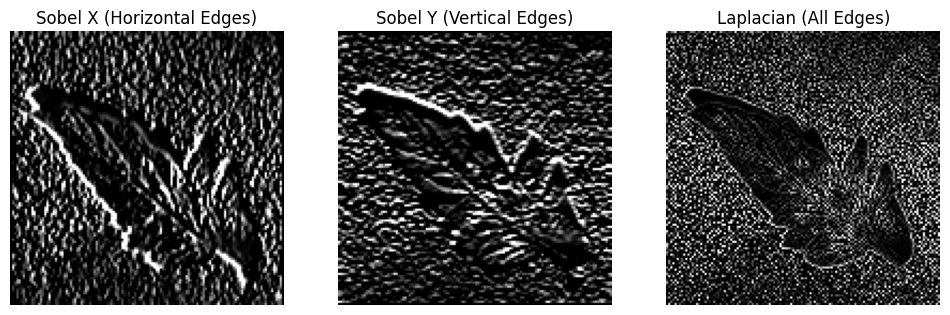

In [18]:
# Apply filters
sobelx, sobely, laplacian = apply_filters(img_processed)

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X (Horizontal Edges)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y (Vertical Edges)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian (All Edges)")
plt.axis('off')

plt.show()

In [19]:
from tqdm import tqdm

X = []
y = []
labels = {}

label_id = 0

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)

    if not os.path.isdir(folder_path):
        continue

    labels[label_id] = folder

    for img_name in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, img_name)

        img = preprocess_image(img_path)
        if img is not None:
            X.append(img)
            y.append(label_id)

    label_id += 1

X = np.array(X)
y = np.array(y)

print("Data Loaded:", X.shape)

100%|██████████| 1404/1404 [00:01<00:00, 1027.02it/s]


Data Loaded: (20638, 128, 128)


In [20]:
X = X / 255.0
X = X.reshape(-1, 128, 128, 1)

print(X.shape)

(20638, 128, 128, 1)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)

(16510, 128, 128, 1)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model_fc = Sequential([
    Flatten(input_shape=(128,128,1)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(len(labels), activation='softmax')
])

model_fc.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fc = model_fc.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - accuracy: 0.2815 - loss: 2.4571 - val_accuracy: 0.4060 - val_loss: 1.9505
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.3919 - loss: 1.9077 - val_accuracy: 0.3956 - val_loss: 1.8510
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.4200 - loss: 1.7811 - val_accuracy: 0.4278 - val_loss: 1.7587
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.4519 - loss: 1.6904 - val_accuracy: 0.4675 - val_loss: 1.6817
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.4693 - loss: 1.6192 - val_accuracy: 0.4704 - val_loss: 1.6596


In [ ]:
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=2,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/2
162/516 ━━━━━━━━━━━━━━━━━━━━ 8:22 1s/step - accuracy: 0.2641 - loss: 2.2555

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
X_rgb = np.repeat(X, 3, axis=-1)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(labels), activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

history_tl = model_tl.fit(
    X_rgb, y,
    epochs=5,
    validation_split=0.2,
    callbacks=[lr_scheduler]
)

In [ ]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    X_rgb, y,
    epochs=5,
    validation_split=0.2
)

In [ ]:
# Evaluation
print("CNN Accuracy:")
model_cnn.evaluate(X_test, y_test)

print("FC Accuracy:")
model_fc.evaluate(X_test, y_test)